In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("cleaned_car_data.csv")
df.tail()

,marketplace_listing_title,vehicle_exterior_color,vehicle_fuel_type,vehicle_make_display_name,vehicle_model_display_name,vehicle_transmission_type,kms,price,state,year
9103,2019 Ford RANGER WILDTRAK PX MKlll AUTO,silver,DIESEL,FORD,RANGER,AUTOMATIC,247000,27999,SA,2019
9104,2002 Mercedes-Benz Sedan,white,PETROL,MERCEDES-BENZ,SEDAN,AUTOMATIC,181000,5900,SA,2002
9105,2021 Nissan Qashqai,grey,PETROL,NISSAN,QASHQAI,AUTOMATIC,67502,24950,VIC,2021
9106,2013 Hyundai 2013 Hyundai ix35 LM3 Elite Wagon...,grey,PETROL,HYUNDAI,IX35,AUTOMATIC,232045,8990,VIC,2013
9107,2015 Mitsubishi Lancer,white,PETROL,MITSUBISHI,LANCER,AUTOMATIC,252433,9500,VIC,2015


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9108 entries, 0 to 9107
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   marketplace_listing_title   9108 non-null   object
 1   vehicle_exterior_color      9108 non-null   object
 2   vehicle_fuel_type           9108 non-null   object
 3   vehicle_make_display_name   9108 non-null   object
 4   vehicle_model_display_name  9108 non-null   object
 5   vehicle_transmission_type   9108 non-null   object
 6   kms                         9108 non-null   int64 
 7   price                       9108 non-null   int64 
 8   state                       9108 non-null   object
 9   year                        9108 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 711.7+ KB


In [4]:
df.shape

(9108, 10)

In [5]:
df.columns

Index(['marketplace_listing_title', 'vehicle_exterior_color',
       'vehicle_fuel_type', 'vehicle_make_display_name',
       'vehicle_model_display_name', 'vehicle_transmission_type', 'kms',
       'price', 'state', 'year'],
      dtype='object')

In [6]:
df.describe()

,kms,price,year
count,9108.000000,9108.000000,9108.000000
mean,173467.056214,19386.209925,2011.127580
std,100870.312383,19795.734549,8.741029
min,300.000000,2500.000000,1942.000000
25%,106000.000000,7000.000000,2008.000000
50%,167000.000000,13000.000000,2012.000000
75%,230000.000000,24262.500000,2017.000000
max,1000000.000000,195000.000000,2026.000000


In [7]:
df.duplicated().sum()

np.int64(12)

In [8]:
df.isnull().sum()

marketplace_listing_title     0
vehicle_exterior_color        0
vehicle_fuel_type             0
vehicle_make_display_name     0
vehicle_model_display_name    0
vehicle_transmission_type     0
kms                           0
price                         0
state                         0
year                          0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.shape

(9108, 10)

In [11]:
df.drop_duplicates(inplace=True)
df.shape

(9096, 10)

In [12]:
df.dtypes

marketplace_listing_title     object
vehicle_exterior_color        object
vehicle_fuel_type             object
vehicle_make_display_name     object
vehicle_model_display_name    object
vehicle_transmission_type     object
kms                            int64
price                          int64
state                         object
year                           int64
dtype: object

In [13]:
garbage_prices = [123456, 111111, 1234, 1, 0]
df = df[~df["price"].isin(garbage_prices)]

In [14]:
garbage_kms = [123456, 111111, 1234, 1, 0]
df = df[~df["kms"].isin(garbage_kms)]

In [15]:
df.shape

(9010, 10)

# Eda

In [16]:
df.tail()

,marketplace_listing_title,vehicle_exterior_color,vehicle_fuel_type,vehicle_make_display_name,vehicle_model_display_name,vehicle_transmission_type,kms,price,state,year
9103,2019 Ford RANGER WILDTRAK PX MKlll AUTO,silver,DIESEL,FORD,RANGER,AUTOMATIC,247000,27999,SA,2019
9104,2002 Mercedes-Benz Sedan,white,PETROL,MERCEDES-BENZ,SEDAN,AUTOMATIC,181000,5900,SA,2002
9105,2021 Nissan Qashqai,grey,PETROL,NISSAN,QASHQAI,AUTOMATIC,67502,24950,VIC,2021
9106,2013 Hyundai 2013 Hyundai ix35 LM3 Elite Wagon...,grey,PETROL,HYUNDAI,IX35,AUTOMATIC,232045,8990,VIC,2013
9107,2015 Mitsubishi Lancer,white,PETROL,MITSUBISHI,LANCER,AUTOMATIC,252433,9500,VIC,2015


In [17]:
df.columns

Index(['marketplace_listing_title', 'vehicle_exterior_color',
       'vehicle_fuel_type', 'vehicle_make_display_name',
       'vehicle_model_display_name', 'vehicle_transmission_type', 'kms',
       'price', 'state', 'year'],
      dtype='object')

<Axes: xlabel='price', ylabel='Count'>

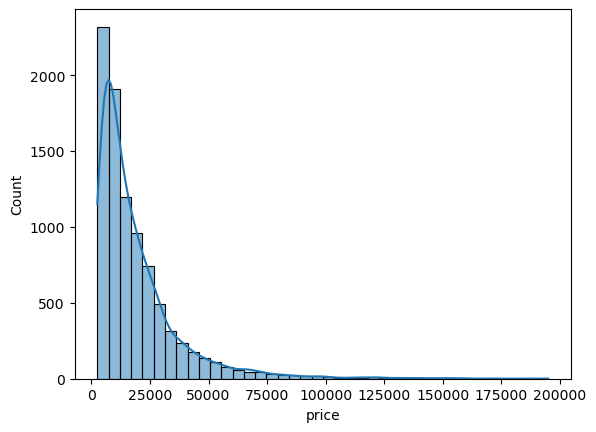

In [18]:
sns.histplot(df["price"], bins=40, kde=True)

- This plot shows the overall distribution of car prices in the dataset. 
- Most cars are listed at lower prices, while a smaller number of very expensive cars create a long right tail, making the distribution **right-skewed**. 
- These high-price values are treated as valid extreme cases rather than removed, since keeping them helps the model learn patterns for **premium/high-priced cars**.

<Axes: xlabel='kms', ylabel='Count'>

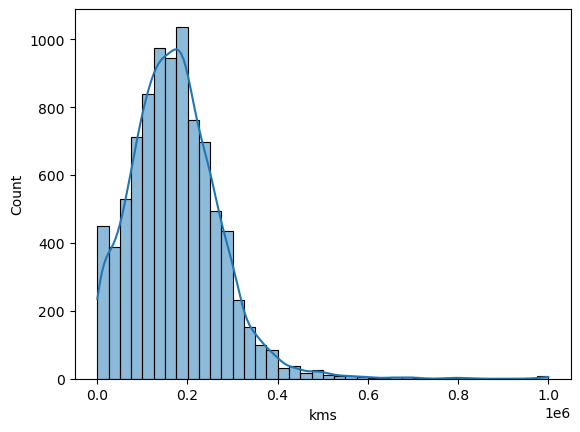

In [19]:
sns.histplot(df["kms"], bins=40, kde=True)

- This plot shows the distribution of kilometers driven across all listed cars. 
- Most vehicles fall in a moderate mileage range, while a smaller number of cars have very high mileage, creating a **right-skewed** distribution.
- This helps identify typical usage patterns and highlights extreme high-mileage vehicles present in the dataset.


In [20]:
df[['kms','price']].corr()

,kms,price
kms,1.000000,-0.364204
price,-0.364204,1.000000


<Axes: xlabel='kms', ylabel='price'>

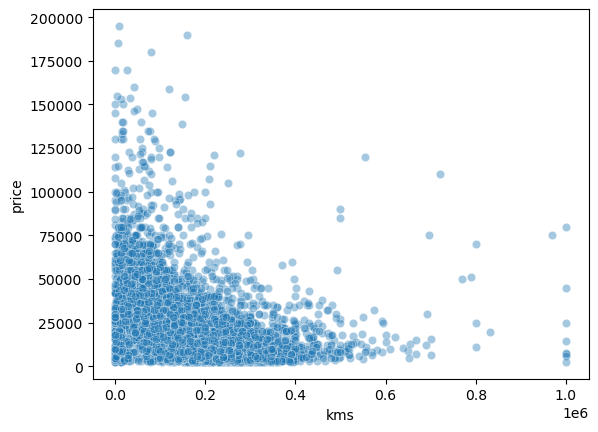

In [32]:
sns.scatterplot(data=df, x="kms", y="price", alpha=0.4)

- This scatter plot shows the relationship between car price and kilometers driven.
- In general, as **kms increase, price tends to decrease**, reflecting vehicle depreciation.
- The plot also contains a few extreme high-price points, indicating premium listings or outliers that can influence model learning.


<Axes: xlabel='vehicle_fuel_type', ylabel='price'>

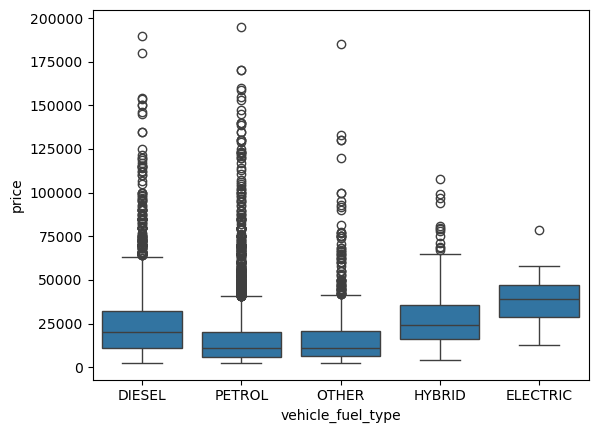

In [33]:
sns.boxplot(x='vehicle_fuel_type', y='price', data=df)

The boxplot highlights clear price differences across fuel types.

- **Electric vehicles** have the highest median price, indicating premium positioning.
- **Hybrid vehicles** are priced higher than Petrol and Diesel.
- **Petrol cars** generally show lower median prices with high variability.
- Multiple outliers suggest the presence of luxury models in each category.

**Insight:** Fuel type is a strong categorical feature and has a significant impact on vehicle pricing.


<Axes: xlabel='vehicle_fuel_type', ylabel='price'>

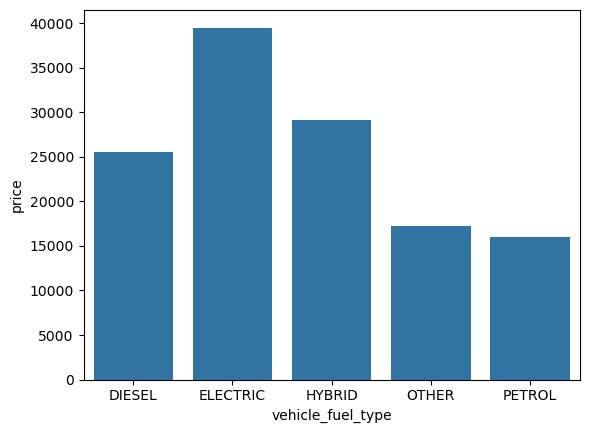

In [35]:
avg_price_fuel = (
    df.groupby('vehicle_fuel_type')['price']
      .mean()
      .reset_index()
)
sns.barplot(
    x='vehicle_fuel_type',
    y='price',
    data=avg_price_fuel
)

The bar chart shows the average vehicle price across different fuel categories.

- **Electric vehicles** have the highest average price, reflecting premium pricing.
- **Hybrid vehicles** are priced higher than conventional fuel types.
- **Diesel** vehicles fall in the mid-price range.
- **Petrol** and **Other** fuel types show lower average prices.

**Insight:** Fuel type has a clear impact on average vehicle pricing.

<Axes: xlabel='vehicle_transmission_type', ylabel='price'>

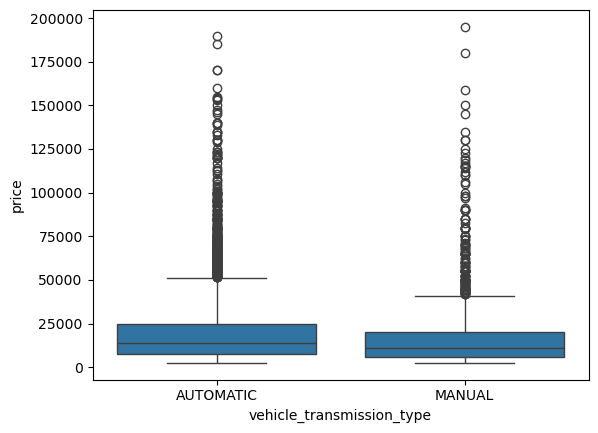

In [23]:
sns.boxplot(x='vehicle_transmission_type', y='price', data=df)

The boxplot shows that **automatic transmission vehicles** have a higher median
price compared to manual vehicles.

- Automatic cars generally command a price premium.
- Manual cars show lower median prices with wider variability.
- High-value outliers exist in both categories, indicating premium models.

<Axes: xlabel='vehicle_transmission_type', ylabel='price'>

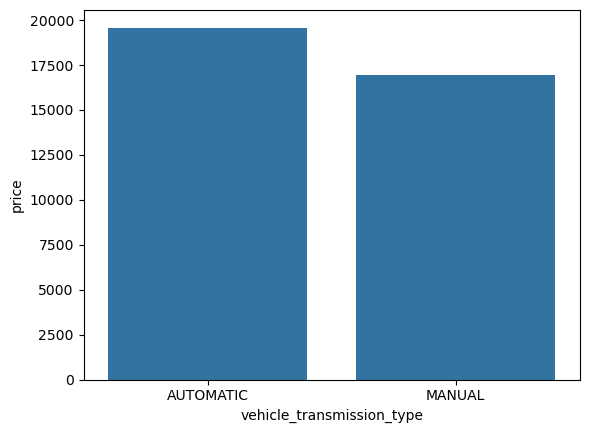

In [37]:
avg_price_transmission = (
    df.groupby('vehicle_transmission_type')['price']
      .mean()
      .reset_index()
)
sns.barplot(
    x='vehicle_transmission_type',
    y='price',
    data=avg_price_transmission
)

The bar chart compares the average vehicle price across transmission types.

- **Automatic vehicles** have a higher average price than manual vehicles.
- **Manual vehicles** are generally more affordable on average.

**Insight:** Transmission type influences vehicle pricing and should be considered
during modeling.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'CHEVROLET'),
  Text(1, 0, 'PORSCHE'),
  Text(2, 0, 'TESLA'),
  Text(3, 0, 'HSV'),
  Text(4, 0, 'IVECO'),
  Text(5, 0, 'DODGE'),
  Text(6, 0, 'ISUZU'),
  Text(7, 0, 'HINO'),
  Text(8, 0, 'MERCEDES-BENZ'),
  Text(9, 0, 'LAND-ROVER')])

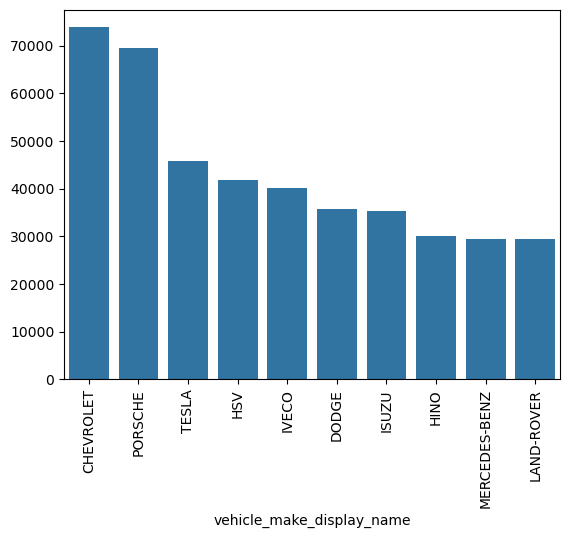

In [24]:
avg_price_make = (
    df.groupby("vehicle_make_display_name")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(x=avg_price_make.index, y=avg_price_make.values)
plt.xticks(rotation=90)

- This bar chart presents the average vehicle price across the top manufacturers in the dataset.  
- Luxury and premium brands such as **Porsche** and **Chevrolet** command significantly higher average prices, while commercial and mass-market brands appear in the mid to lower price range.

The clear price variation across manufacturers indicates that vehicle make is a strong predictor of price and should be treated as an important feature during modeling.


<Axes: xlabel='year', ylabel='price'>

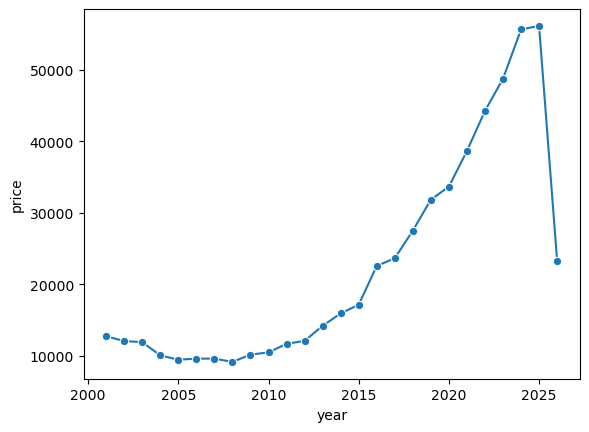

In [61]:
yer_df = df[df["year"]>2000]
year_price = (
    yer_df.groupby('year')['price']
      .mean()
      .reset_index()
)
sns.lineplot(x='year', y='price', data=year_price, marker='o')


The line plot shows a clear relationship between vehicle age and price.

- Newer vehicles generally have higher average prices.
- Prices decrease as vehicles get older due to depreciation.
- Recent years show a rising trend, reflecting increased vehicle costs.
- This data start from year 2000 and good correlation but data is decreased from 9010 to 8334 but lead to increase in correlation from 0.27 to 0.54

In [41]:
df[df["year"]<1960]

,marketplace_listing_title,vehicle_exterior_color,vehicle_fuel_type,vehicle_make_display_name,vehicle_model_display_name,vehicle_transmission_type,kms,price,state,year
552,1955 Ford Fairlane,red,PETROL,FORD,FAIRLANE,AUTOMATIC,300,95000,WA,1955
6042,1942 Ford F-350,yellow,DIESEL,FORD,F-350,AUTOMATIC,7000,70000,VIC,1942
9018,1948 Ford F-100,black,PETROL,FORD,F-100,AUTOMATIC,666,70000,VIC,1948


<Axes: ylabel='state'>

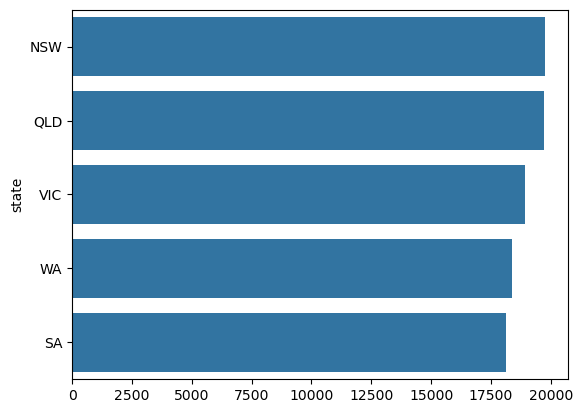

In [42]:
avg_price_state = (
    df.groupby("state")["price"]
    .mean()
    .sort_values(ascending=False)
)
sns.barplot(x=avg_price_state.values, y=avg_price_state.index)

- This bar chart represents the **average vehicle price across different states**.  
- **NSW** has the highest average car price, indicating more premium or newer listings in that state.  
- It is mostly the sme
  
This highlights that **state/location impacts vehicle pricing very less**, so it is not an important feature for price prediction modeling.


<Axes: xlabel='vehicle_exterior_color'>

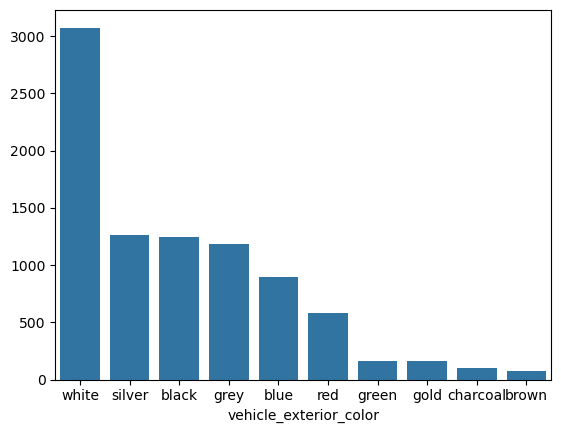

In [43]:
top_ext_colors = df["vehicle_exterior_color"].value_counts().head(10)
sns.barplot(x=top_ext_colors.index, y=top_ext_colors.values)

- This bar chart shows the **Top 10 most common exterior colors** of vehicles in the dataset.  
- **White** is the most frequently listed color, followed by **black**, **silver**, and **grey**, showing strong market preference for neutral colors.  - Rare colors such as **gold, charcoal, and brown** appear in very small numbers.  

This indicates that exterior color trends are highly skewed toward popular shades, and color may have a minor but noticeable influence on demand and pricing.

<Axes: xlabel='vehicle_exterior_color', ylabel='price'>

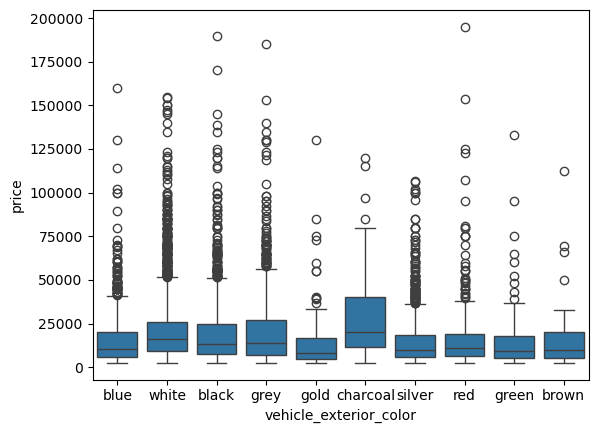

In [48]:
top_colors = df['vehicle_exterior_color'].value_counts().head(10).index
df_top_colors = df[df['vehicle_exterior_color'].isin(top_colors)]

sns.boxplot(
    x='vehicle_exterior_color',
    y='price',
    data=df_top_colors
)

The boxplot compares vehicle price distributions across the most common exterior
colors.

- Price ranges overlap significantly across all colors.
- Neutral colors such as **white, black, and grey** show slightly higher medians,
likely due to higher market demand.
- Several high-price outliers exist for every color category.

**Insight:** While this relationship may not be very meaningful, the visualization helps demonstrate that color does not significantly affect price, which supports excluding it from the ML model.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'COMMODORE'),
  Text(1, 0, 'LANDCRUISER'),
  Text(2, 0, 'RANGER'),
  Text(3, 0, 'HILUX'),
  Text(4, 0, 'COROLLA'),
  Text(5, 0, 'CAMRY'),
  Text(6, 0, 'GOLF'),
  Text(7, 0, 'FALCON'),
  Text(8, 0, 'NAVARA'),
  Text(9, 0, 'I30')])

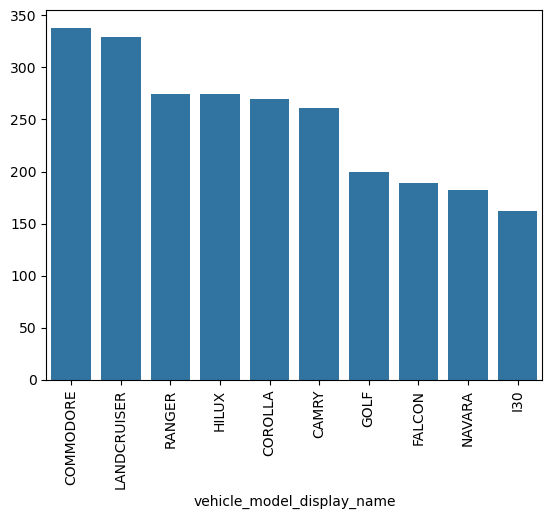

In [29]:
top_models = df["vehicle_model_display_name"].value_counts().head(10)
sns.barplot(x=top_models.index, y=top_models.values)
plt.xticks(rotation=90)

- This bar chart displays the **Top 10 most frequently listed vehicle models** in the dataset.  
- Models like **Commodore, Land Cruiser, and Ranger** appear most often, indicating they are highly popular and commonly available in the market.  
- The presence of repeated mainstream models suggests the dataset is dominated by **high-demand, mass-market vehicles**.  

This insight is useful because popular models may have more stable pricing patterns, and **vehicle model can be a strong predictor of price** during modeling.


## Final EDA Conclusion

Strong predictors: vehicle_make_display_name, vehicle_model_display_name, vehicle_fuel_type, vehicle_transmission_type, kms, year

Weak or non-predictors: vehicle_exterior_color, state

Index(['marketplace_listing_title', 'vehicle_exterior_color',
       'vehicle_fuel_type', 'vehicle_make_display_name',
       'vehicle_model_display_name', 'vehicle_transmission_type', 'kms',
       'price', 'state', 'year'],
      dtype='object')

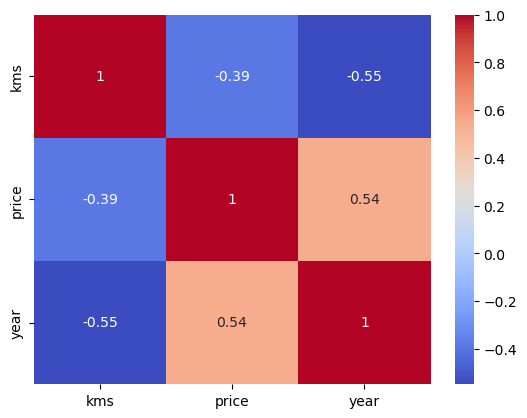

In [65]:
corr = yer_df.corr(numeric_only=True)
sns.heatmap(data=corr, annot=True, cmap='coolwarm')
df.columns